In [154]:
import os
from openimages.download import download_dataset

In [155]:
data_dir = 'data'
number_of_samples = 350
classes = ['Missile', 'Balloon', 'Castle']

In [156]:
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [157]:
if not (os.path.exists(os.path.join(data_dir, classes[0].lower())) and
        os.path.exists(os.path.join(data_dir, classes[1].lower())) and
        os.path.exists(os.path.join(data_dir, classes[2].lower()))):
    download_dataset(data_dir, classes, limit=number_of_samples)

In [158]:
import torch
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from skimage import io
from skimage.transform import resize
from skimage.color import gray2rgb
import glob
import matplotlib.pyplot as plt

In [159]:
def read_img(file_name):
    img = io.imread(file_name)
    if img.ndim == 2:
        img = gray2rgb(img)
    img = resize(img, (224, 224))
    img = torch.tensor(img)
    img = img.permute(2, 0, 1)
    return img.float()

In [160]:
class CustomDataset(Dataset):
    def __init__(self, images_dir):
        self.images_dir = images_dir
        self.transforms = transforms

        self.class1_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[0].lower()))
        self.class2_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[1].lower()))
        self.class3_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[2].lower()))
        self.class1_len = len(self.class1_files)
        self.class2_len = len(self.class2_files)
        self.class3_len = len(self.class3_files)

        self.files = self.class1_files + self.class2_files + self.class3_files

        self.labels = np.zeros(len(self.files))
        self.labels[self.class1_len:self.class1_len + self.class2_len] = 1
        self.labels[self.class1_len + self.class2_len:] = 2

        self.order = [x for x in np.random.permutation(len(self.labels))]
        self.files = [self.files[x] for x in self.order]
        self.labels = [self.labels[x] for x in self.order]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        file = self.files[i]
        im = read_img(file)

        img = im.clone().detach()

        y = self.labels[i]
        return img, y

In [161]:
dataset = CustomDataset('./data')
len(dataset)

957

In [162]:
print(dataset[0][0].shape, dataset[0][1])

torch.Size([3, 224, 224]) 0.0


In [163]:
train_dataset = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=2)
iterator = iter(train_dataset)

In [164]:
images, labels = next(iterator)

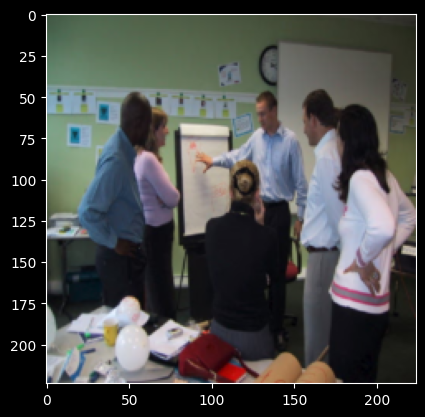

In [165]:
plt.imshow(images[0].permute(1, 2, 0))


In [166]:
from torchvision.models import resnet50, ResNet50_Weights

In [167]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()
pass

In [168]:
batch = images[0]
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
batch = (batch - mean) / std

batch = images[0].unsqueeze(0)
batch.shape

torch.Size([1, 3, 224, 224])

In [169]:
prediction = model(batch).squeeze(0).softmax(0)
prediction.shape

torch.Size([1000])

In [170]:
top_3_idx = prediction.argsort(descending=True)[:3]
score_list = prediction[top_3_idx]
score_list

tensor([0.0702, 0.0382, 0.0176], grad_fn=<IndexBackward0>)

In [171]:
category_names = [weights.meta['categories'][i] for i in top_3_idx.numpy()]
category_names

['barbershop', 'lab coat', 'soccer ball']

In [173]:
for category, score in list(zip(category_names, score_list)):
    print(f'{category}: {100 * score:.3f}%')


print(category_names[0] == classes[int(labels[0])].lower())
print(classes[int(labels[0])])

barbershop: 7.019%
lab coat: 3.822%
soccer ball: 1.764%
False
Balloon
